### Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install unrar tree
!pip install ipecharts

### Data Extract

In [ ]:
!unrar x /content/drive/MyDrive/TUKL/data_online_line_width_alpha.rar "*.csv" /content/
!mv /content/data_online_line_width_alpha/ /content/hwd/

In [ ]:
!tree -L 1 /content/hwd/

/content/hwd/
├── Dataset
├── main_1000.csv
├── main_1500.csv
├── main_2000.csv
├── main_2500.csv
├── main_3000.csv
├── main_3500.csv
├── main_5000.csv
├── main_6000.csv
├── test.csv
├── test_extended.csv
├── test_leakproof.csv
├── test_leakproof_raw.csv
├── train.csv
├── train_extended.csv
├── train_leakproof.csv
├── train_leakproof_raw.csv
├── val.csv
├── val_extended.csv
├── val_leakproof.csv
└── val_leakproof_raw.csv

1 directory, 20 files


In [2]:
import pandas as pd

df = pd.read_csv('/content/hwd/main_1500.csv')
print(df.shape)
df.head(2)

(253, 7)


,id,cms,gender,age,csv,img,line
0,0,461136,f,21,Dataset/Data_1500/csv/csv_0000_0.csv,Dataset/Data_1500/img/img_0000_0.png,پڑھی گئیں کہ ٹرکوں کے ٹرک امدادی سامان سے بھرے
1,0,461136,f,21,Dataset/Data_1500/csv/csv_0000_1.csv,Dataset/Data_1500/img/img_0000_1.png,نہ دیتا تو آپؒ اس پر ناراضگی کا اظہار کرتے


In [27]:
data = pd.read_csv('/content/hwd/Dataset/Data_1500/csv/csv_0000_0.csv')
data.head()[['X cood.','Y cood.','Time']]

,X cood.,Y cood.,Time
0,15527,519,0
1,15468,518,2
2,15453,515,4
3,15440,504,6
4,15423,486,8


In [28]:
binned = pd.cut(data['pen_down'], bins=10)

# Count per bin
counts = binned.value_counts().sort_index()
print(counts)

pen_down
(-0.001, 0.1]    6342
(0.1, 0.2]          0
(0.2, 0.3]          0
(0.3, 0.4]          0
(0.4, 0.5]          0
(0.5, 0.6]          0
(0.6, 0.7]          0
(0.7, 0.8]          0
(0.8, 0.9]          0
(0.9, 1.0]       8387
Name: count, dtype: int64


### Data Prep

In [29]:
import glob
import pandas as pd

# Combine main files into one dataframe
main_files = glob.glob('/content/hwd/main_*.csv')
main_files_df = pd.concat((pd.read_csv(f) for f in main_files), ignore_index=True)

main_files_df.head()

,id,gender,age,csv,img,line,cms
0,0,f,19,Dataset/Data_1000/csv/csv_0000_0.csv,Dataset/Data_1000/img/img_0000_0.png,کے درمیان رہنے کا امکان ہے۔ رواں مالی سال 2010-11,NaN
1,0,f,19,Dataset/Data_1000/csv/csv_0000_1.csv,Dataset/Data_1000/img/img_0000_1.png,سب سے بڑا ہوں۔ (۶۴)ذکر سے جنت میں گھر تعمیر,NaN
2,0,f,19,Dataset/Data_1000/csv/csv_0000_2.csv,Dataset/Data_1000/img/img_0000_2.png,لاہور( پ ر)پاکستان مسلم لیگ (ن) اوورسیز کے مرکزی,NaN
3,0,f,19,Dataset/Data_1000/csv/csv_0000_3.csv,Dataset/Data_1000/img/img_0000_3.png,سیکرٹری آئما خطباء نے حکومت سے مطالبہ کیا کہ ش...,NaN
4,0,f,19,Dataset/Data_1000/csv/csv_0000_4.csv,Dataset/Data_1000/img/img_0000_4.png,لیں ، قبائلی رہنماوٴں نے سینیٹ میں شمالی وزیر ...,NaN


In [3]:
import pandas as pd
import glob

meta_files = glob.glob('/content/hwd/main_*.csv')
samples = []
for f in meta_files:
    df = pd.read_csv(f)
    full_paths = '/content/hwd/' + df['csv']
    samples.extend(full_paths.tolist())

# Write the list to a file that bash can read
with open('/content/samples.txt', 'w') as f:
    f.write('\n'.join(samples))

print(f"Extracted {len(samples)} data files")

Extracted 2403 data files


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

def process_sample(file_path, distance=100) -> np.ndarray | None:
    df = pd.read_csv(
        file_path,
        usecols=['X cood.', 'Y cood.', 'Time', 'pen_down'],
        engine='pyarrow'          # pip install pyarrow  (already in Colab)
    )

    df = df[df['pen_down'] > 0.9]
    df = df.sort_values('Time').reset_index(drop=True)
    df = df.rename(columns={'X cood.': 'x', 'Y cood.': 'y'})

    if len(df) < 2:
        return None

    xy = df[['x', 'y']].to_numpy(dtype=np.float32)
    kept = _filter_by_distance(xy, distance)
    xy = xy[kept]

    if len(xy) < 10:
        return None

    return xy


def _filter_by_distance(xy: np.ndarray, min_dist: float) -> np.ndarray:
    if len(xy) == 0:
        return np.array([], dtype=bool)

    # Compute displacement between every consecutive pair
    deltas = np.diff(xy, axis=0)                        # (N-1, 2)
    dists  = np.sqrt((deltas ** 2).sum(axis=1))         # (N-1,)

    # Cumulative distance travelled along the path
    cumdist = np.concatenate([[0.0], np.cumsum(dists)]) # (N,)

    # Keep a point whenever we've travelled >= min_dist since the last kept point
    kept    = [0]
    last_d  = 0.0
    # This loop is over *kept* points (much shorter than N), not all N rows
    thresholds = cumdist
    for i in range(1, len(xy)):
        if thresholds[i] - last_d >= min_dist:
            kept.append(i)
            last_d = thresholds[i]

    return np.array(kept, dtype=np.int64)


def plot_sample(data: np.ndarray) -> None:
    plt.figure(figsize=(8, 1))
    plt.scatter(data[:, 0], data[:, 1], s=0.2, c='blue', alpha=0.8)
    plt.axis('equal')
    plt.axis('off')
    plt.gca().invert_yaxis()
    plt.show()


def process_samples(file_paths: list[str],distance: int = 100, n_workers: int = 4,out_dir: str | None = None) -> list[np.ndarray]:
    if out_dir:
        Path(out_dir).mkdir(exist_ok=True)

    results = {}
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        futures = {
            pool.submit(_worker, p, distance, out_dir): p
            for p in file_paths
        }
        for fut in tqdm(as_completed(futures), total=len(file_paths)):
            path = futures[fut]
            try:
                results[path] = fut.result()
            except Exception as e:
                print(f"Failed: {path} — {e}")
                results[path] = None

    # Return in original order, filtering out None
    return [results[p] for p in file_paths if results.get(p) is not None]


def _worker(path: str, distance: int, out_dir: str | None):
    """Runs in a subprocess — must be a module-level function (pickle requirement)."""
    arr = process_sample(path, distance=distance)
    if arr is None:
        return None

    # Normalize
    arr = arr - arr[0]
    scale = np.max(np.abs(arr)) + 1e-8
    arr = arr / scale

    if out_dir:
        filename = f"csv_{Path(path).parent.parent.name.split('_')[-1]}_{Path(path).stem.split('_', 1)[1]}"
        np.savez(
            Path(out_dir) / f"{filename}.npz",
            points=arr,
            gt_order=np.arange(len(arr), dtype=np.int64)
        )
        return filename
    return arr

305


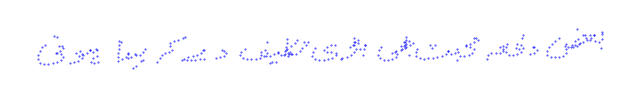

In [6]:
sample = process_sample('/content/hwd/Dataset/Data_2000/csv/csv_0005_2.csv')
print(len(sample))
plot_sample(sample)

In [7]:
sample_paths = open('/content/samples.txt').read().splitlines()
data = process_samples(sample_paths, out_dir='/content/processed/')

100%|██████████| 2403/2403 [00:46<00:00, 51.24it/s]


In [ ]:
!ls /content/processed/ | tail -n 5

csv_6000_0042_3.npz
csv_6000_0042_4.npz
csv_6000_0042_5.npz
csv_6000_0042_6.npz
csv_6000_0042_7.npz


### Model

#### Data Loader

In [19]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

class HandwritingDataset(Dataset):
    def __init__(self, npz_dir: str):
        self.files = list(Path(npz_dir).glob('*.npz'))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        points   = torch.tensor(data['points'],   dtype=torch.float32)
        gt_order = torch.tensor(data['gt_order'], dtype=torch.long)

        return points, gt_order

In [20]:
def collate_fn(batch):
    points_list, order_list = zip(*batch)

    lengths = torch.tensor([len(p) for p in points_list])

    # Pad points with 0.0, gt_order with -1 (so loss can ignore pad positions)
    points_padded = torch.zeros(len(batch), lengths.max(), 2)
    orders_padded = torch.full((len(batch), lengths.max()), fill_value=-1, dtype=torch.long)

    for i, (pts, ord_) in enumerate(zip(points_list, order_list)):
        n = len(pts)
        points_padded[i, :n] = pts
        orders_padded[i, :n] = ord_

    return points_padded, orders_padded, lengths

In [21]:
dataset = HandwritingDataset('/content/processed/')

# 80/20 train-val split
val_size   = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

In [22]:
points, gt_order, lengths = next(iter(train_loader))

print("points shape :", points.shape)    # (32, N_max, 2)
print("gt_order shape:", gt_order.shape) # (32, N_max)
print("lengths      :", lengths[:8])     # first 8 sequence lengths
print("padding check:", (gt_order[0] == -1).sum().item(), "pad positions in sample 0")

points shape : torch.Size([32, 428, 2])
gt_order shape: torch.Size([32, 428])
lengths      : tensor([303, 259, 361, 428, 327, 269, 274, 304])
padding check: 125 pad positions in sample 0


#### Training

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointerNetwork(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(2, d_model)

        # Transformer encoder — lets every point look at every other point
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Decoder memory — tracks "what have I picked so far"
        self.decoder_gru = nn.GRUCell(d_model, d_model)

        # Scoring: compares decoder state against each encoder output
        self.attn_W = nn.Linear(d_model, d_model)
        self.attn_V = nn.Linear(d_model, 1)

    def forward(self, points, lengths, target_order=None):
        B, N, _ = points.shape

        # --- Encoder ---
        pad_mask = torch.arange(N, device=points.device).unsqueeze(0) >= lengths.unsqueeze(1)

        h = self.input_proj(points)
        enc = self.encoder(h, src_key_padding_mask=pad_mask)
        enc = enc.masked_fill(pad_mask.unsqueeze(-1), 0.0)

        # --- Decoder ---
        mask_float = (~pad_mask).unsqueeze(-1).float()
        decoder_h = (enc * mask_float).sum(dim=1) / mask_float.sum(dim=1)

        logits_seq = []
        chosen = pad_mask.clone().detach()

        max_steps = lengths.max().item()
        for step in range(max_steps):
            scores = self.attn_V(
                torch.tanh(self.attn_W(enc) + decoder_h.unsqueeze(1))
            ).squeeze(-1)

            # Use -1e9 instead of -inf to prevent gradient anomalies
            scores = scores.masked_fill(chosen, -1e9)
            logits_seq.append(scores)

            # --- THE FIX: Teacher Forcing ---
            if target_order is not None:
                # Training/Validation loss mode: use ground truth to drive the state
                idx = target_order[:, step].clone()
                # Handle padding (-1) so scatter doesn't throw an out-of-bounds error
                idx[idx == -1] = 0
            else:
                # Inference mode: use model's own predictions
                idx = scores.argmax(dim=-1)

            chosen = chosen.scatter(1, idx.unsqueeze(1), True)

            picked = enc[torch.arange(B), idx]
            decoder_h = self.decoder_gru(picked, decoder_h)

        return torch.stack(logits_seq, dim=1)

In [24]:
# ── Loss ──────────────────────────────────────────────────────────────────────
def pointer_loss(logits, gt_order):
    B, S, N = logits.shape   # S = max_steps (< N when batch has padding)

    target = gt_order[:, :S]                        # (B, S)

    logits_flat = logits.reshape(B * S, N)
    target_flat = target.reshape(B * S)

    return F.cross_entropy(logits_flat, target_flat, ignore_index=-1)

In [25]:
# Run this ONCE before the training loop
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = PointerNetwork(d_model=128, nhead=4, num_layers=3).to(device)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

points, gt_order, lengths = next(iter(train_loader))
points   = points.to(device)
gt_order = gt_order.to(device)
lengths  = lengths.to(device)

print("lengths sample:  ", lengths[:4])
print("max length:      ", lengths.max().item())
print("points shape:    ", points.shape)
print("gt_order sample: ", gt_order[0, :5])

# Check the padding mask
N = points.shape[1]
pad_mask = torch.arange(N, device=device).unsqueeze(0) >= lengths.unsqueeze(1)
print("\npad_mask shape:  ", pad_mask.shape)
print("real positions in sample 0:", (~pad_mask[0]).sum().item(), "of", N)
print("pad_mask dtype:  ", pad_mask.dtype)

print("gt_order max:", gt_order[gt_order != -1].max().item())
print("gt_order min:", gt_order[gt_order != -1].min().item())
print("logits N dim:", points.shape[1])  # gt_order values must all be < this

# Check encoder output
model.eval()
with torch.no_grad():
    h = model.input_proj(points)
    enc = model.encoder(h, src_key_padding_mask=pad_mask)
    print("\nenc has nan:", torch.isnan(enc).any().item())
    print("enc has inf:", torch.isinf(enc).any().item())

    # Check scores at step 0
    mask_float = (~pad_mask).unsqueeze(-1).float()
    decoder_h  = (enc * mask_float).sum(dim=1) / mask_float.sum(dim=1)
    scores = model.attn_V(
        torch.tanh(model.attn_W(enc) + decoder_h.unsqueeze(1))
    ).squeeze(-1)

    chosen = pad_mask.clone().detach()
    scores_masked = scores.masked_fill(chosen, float('-inf'))

    print("\nscores min/max (before mask):", scores.min().item(), scores.max().item())
    print("all scores -inf after mask?  ", (scores_masked == float('-inf')).all(dim=-1).any().item())
    print("num valid positions sample 0:", (scores_masked[0] != float('-inf')).sum().item())

Training on: cuda
lengths sample:   tensor([277, 270, 287, 383], device='cuda:0')
max length:       478
points shape:     torch.Size([32, 478, 2])
gt_order sample:  tensor([0, 1, 2, 3, 4], device='cuda:0')

pad_mask shape:   torch.Size([32, 478])
real positions in sample 0: 277 of 478
pad_mask dtype:   torch.bool
gt_order max: 477
gt_order min: 0
logits N dim: 478

enc has nan: False
enc has inf: False

scores min/max (before mask): -0.4513833522796631 -0.1616208255290985
all scores -inf after mask?   False
num valid positions sample 0: 277


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = PointerNetwork(d_model=128, nhead=4, num_layers=3).to(device)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Halves the LR if val loss stops improving for 3 epochs
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss = 0

    with torch.set_grad_enabled(training):
        for points, gt_order, lengths in loader:
            points   = points.to(device)
            gt_order = gt_order.to(device)
            lengths  = lengths.to(device)

            # Pass gt_order to enable Teacher Forcing
            logits = model(points, lengths, target_order=gt_order)
            loss   = pointer_loss(logits, gt_order)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)

# --- main training loop ---
EPOCHS = 10
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, training=True)
    val_loss   = run_epoch(val_loader,   training=False)

    scheduler.step(val_loss)

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"Epoch {epoch+1:02d} | train: {train_loss:.4f} | val: {val_loss:.4f}")

Training on: cuda
Epoch 01 | train: 3.7189 | val: 3.2397
Epoch 02 | train: 3.1101 | val: 2.9552
